# intro

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
import matplotlib as mpl


import ipywidgets as widgets
import warnings
warnings.filterwarnings('ignore')

In [2]:
STD_NOISE = 2*10**-1
DIM = 2
NUM_SAMPLES = 15
evals = [1, 2] # underlying singular values
SEED = 19890

ylim = [-1.5, 4]
xlim = [-4, 4]
CONTOUR_LINES = 5
LABELS_FONTSIZE = 14
TITLE_FONTSIZE = 18
SUPTITLE_FONTSIZE = 20
FIGSIZE = (12, 6)
CONTOUR_LOSS_THRESHOLD = 20

STEPS = 100
ROTATION_STEPS = 200
w_1_range = [-2.5, 3]
w_t = [max(w_1_range), 1.8]

FPS = 30
SHOULD_ANIMATE = True


def SVD(M):
    U, D, V = np.linalg.svd(M)  # V ROWS are the eigenvectors
    V = V.T
    S = np.zeros(M.shape, dtype=V.dtype)
    S[:D.shape[0], :D.shape[0]] += np.diag(D)

    return U, S, V

def generateData(NUM_SAMPLES, DIM, STD_NOISE, singularValues):
    # Not really random
    X = np.random.randn(NUM_SAMPLES, DIM)
    U, _, V = SVD(X)

    S = np.zeros(X.shape, dtype=V.dtype)
    S[:len(singularValues), :len(singularValues)] += np.diag(singularValues)
    X = U.dot(S.dot(V.T))

    noise = np.random.randn(NUM_SAMPLES).astype(np.float64) * STD_NOISE

    return X, noise

# Find the suitable lambda for the unconstrained problem
def normToLambda(norm, S, U, y):
    z = S.T.dot(U.T.dot(y))

    minLambda = 10**-5
    maxLambda = 10**5
    currLambda = 10
    eps = 10**-10

    i = 0
    # Since the relation is "monotonic", use binary search
    while True:
        i += 1

        if (i > 10000):
            exit()

        leftSide = (z[0] / (S[0,0] ** 2 + currLambda)) ** 2 + (z[1] / (S[1,1] ** 2 + currLambda)) ** 2

        if leftSide >= norm + eps:
            # Lambda is too small
            minLambda = currLambda
            currLambda = maxLambda - (maxLambda - currLambda) / 2
            continue
        elif leftSide <= norm - eps:
            # Lambda is too large
            maxLambda = currLambda
            currLambda = (currLambda - minLambda) / 2 + minLambda
            continue

        return currLambda

def plotUnitCircle(alpha, fc, lw):
    # Plot unit circle
    unitCircle = plt.Circle((0, 0), 1,
                            alpha=alpha, fc=fc, lw=lw, zorder=10)
    # Draw a non-transparent white edge to wipe the facecolor where they overlap
    c_wipe = plt.Circle((0, 0), 1,
                        alpha=1.0, ec='white', fc='none', lw=lw, zorder=10)
    # Now draw only the edge
    c_edge = plt.Circle((0, 0), 1,
                        fc='none', ec='k', lw=lw)
    unitCircle_patch = PatchCollection([unitCircle, c_wipe, c_edge], match_original=True, zorder=10)
    axes[0].add_artist(unitCircle_patch)

def plotUnitDiamond(alpha, fc, lw):
    # Plot unit diamond
    diagonal = np.sqrt(2)

    rect = patches.Rectangle((-1/np.sqrt(2), -1/np.sqrt(2)), diagonal, diagonal,
                             alpha=alpha, fc=fc, zorder=10)
    # Draw a non-transparent white edge to wipe the facecolor where they overlap
    r_wipe = patches.Rectangle((-1/np.sqrt(2), -1/np.sqrt(2)), diagonal, diagonal,
                               alpha=1.0, ec='white', fc='none', lw=lw, zorder=10)
    # Now draw only the edge
    r_edge =patches.Rectangle((-1/np.sqrt(2), -1/np.sqrt(2)), diagonal, diagonal,
                              fc='none', ec='k', lw=lw)
    t2 = mpl.transforms.Affine2D().rotate_deg(-45) + axes[1].transData
    rect_patch = PatchCollection([rect, r_wipe, r_edge], match_original=True, zorder=10)
    rect_patch.set_transform(t2)

    axes[1].add_artist(rect_patch)

# Create linear range between two points (https://stackoverflow.com/a/46694364/1947677)
def create_ranges_nd(start, stop, N, endpoint=True):
    if endpoint==1:
        divisor = N-1
    else:
        divisor = N
    steps = (1.0/divisor) * (stop - start)
    return start[...,None] + steps[...,None]*np.arange(N)

def errorForSolution(X, y, sol):
    return np.linalg.norm(X.dot(sol) - y) ** 2

def findL1Solution(norm, X, y, unregSol):
    if unregSol[0] >= 0 and unregSol[1] >= 0:
        # First quarter
        p1 = [0, norm]
        p2 = [norm, 0]
    elif unregSol[0] < 0 and unregSol[1] >= 0:
        # Second quarter
        p1 = [0, norm]
        p2 = [-norm, 0]
    elif unregSol[0] < 0 and unregSol[1] < 0:
        # Third quarter
        p1 = [0, -norm]
        p2 = [-norm, 0]
    else:
        # Fourth quarter
        p1 = [0, -norm]
        p2 = [norm, 0]

    # Search between the two points (more candidates => closer to actual solution)
    candidates = create_ranges_nd(np.array(p1), np.array(p2), N=10**3).T
    errors = [errorForSolution(X, y, s) for s in candidates]

    return candidates[np.argmin(errors), :]

# Draw the axes + copyrights + norm circles
def drawStaticShapes(axes):
    for ax in axes:
        # Draw axes
        ax.arrow(xlim[0] + 0.2, 0, xlim[1] - xlim[0] - 0.5, 0., fc='k', ec='k',
                 lw=1.5, head_width=.2, head_length=.2,
                 length_includes_head= True, clip_on = False, zorder=2)

        ax.arrow(0, ylim[0] + 0.2, 0., ylim[1] - ylim[0] - 0.5, fc='k', ec='k',
                 lw=1.5, head_width=.2, head_length=.2,
                 length_includes_head= True, clip_on = False, zorder=2)


    # Plot copyrights
    axes[-1].annotate('adapted from @itayevron',
                fontsize=16, c='grey', zorder=20,
                xy=(1, 0), xytext=(0, 20),
                xycoords=('axes fraction', 'figure fraction'),
                textcoords='offset points',
                ha='right', va='bottom')

    fc = 'c'
    alpha = 0.7
    lw = 2
    plotUnitCircle(alpha, fc, lw)
    plotUnitDiamond(alpha, fc, lw)


def plotSolution(ax, pnt,):
    return ax.scatter(pnt[0], pnt[1], c='orange', s=70, edgecolors='k', zorder=11)

def plotContours(X, y):
    # Gather all discrete points
    delta = np.sqrt(((xlim[1] - xlim[0]) * (ylim[1] - ylim[0])) / 10 ** 6)  # Have one million grids
    Xs = np.arange(xlim[0], xlim[1], delta)
    Ys = np.arange(ylim[0], ylim[1], delta)
    Xpt, Ypt = np.meshgrid(Xs, Ys)
    Xpt2 = np.ravel(Xpt)
    Ypt2 = np.ravel(Ypt)

    # Compute all weight combinations
    Weights = np.array([Xpt2, Ypt2])
    residuals = X.dot(Weights).T - y.T
    losses = np.linalg.norm(residuals, axis=1) ** 2
    Z = losses.reshape(Xpt.shape)

    # Nullify outside a threshold value to create an ellipsis (cleaner view)
    Z[Z > CONTOUR_LOSS_THRESHOLD] = 0

    contours = []
    for ax in axes:
        contours.append(ax.contour(Xpt, Ypt, Z, CONTOUR_LINES, linewidths=1, colors='k'))

    return contours



def rotateProblem(U, S, V, noise, angle):
    theta = angle * np.pi / 180

    # Create rotation matrix and rotate
    currV = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]).dot(V)
    X = U.dot(S.dot(currV.T))
    y = X.dot(w_t) + noise

    return X, y, currV

# demo

interactive(children=(FloatSlider(value=0.20000000000000018, description='β_1', max=3.0, min=-2.5), IntSlider(…

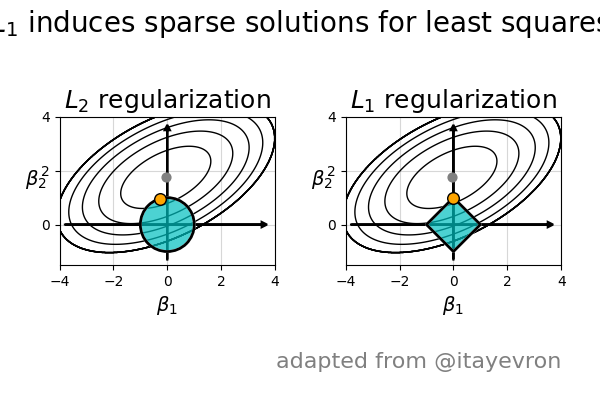

In [3]:
%matplotlib widget


# Plotting starts
fig, axes = plt.subplots(1, 2, figsize=(6,4))
plt.tight_layout(pad=2)
axes = np.ravel(axes)

# Initialize plots and axes
for ax in axes:
    ax.set_aspect('equal', adjustable='box')
    ax.set_aspect('equal', adjustable='box')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.grid(zorder=0, alpha=0.5)
    ax.set_xlabel(r"$\beta_1$", fontsize=LABELS_FONTSIZE)
    ax.set_ylabel(r"$\beta_2$", fontsize=LABELS_FONTSIZE, rotation=0)


# Set titles
plt.suptitle(r"$L_1$ induces sparse solutions for least squares", fontsize=SUPTITLE_FONTSIZE)
axes[0].set_title(r"$L_2$ regularization", fontsize=TITLE_FONTSIZE)
axes[1].set_title(r"$L_1$ regularization", fontsize=TITLE_FONTSIZE)
SHOULD_ANIMATE = False


# Generate data
np.random.seed(SEED)
X, noise = generateData(NUM_SAMPLES, DIM, STD_NOISE, evals)

y = X.dot(w_t) + noise
U, S, V = SVD(X)



drawStaticShapes(axes)
plottedPoints = []
contours = plotContours(X, y)

@widgets.interact(angle=(0, 360, 5), β_1=(min(w_1_range), max(w_1_range), .1))
def update(β_1, angle):
    global plottedPoints
    global contours
    w_t[0] = β_1

    X, y, currV = rotateProblem(U, S, V, noise, angle)
    y = X.dot(w_t) + noise

    # plot(X, U, S, currV, y)
    for cntr in contours:
        cntr.remove()

    for pnt in plottedPoints:
        try:
            pnt.remove()
        except:
            pass

    # plt.pause(0.01)
    # Find unconstrained (=unregularized solution)
    unregSol = currV.dot(np.linalg.pinv(S).dot(U.T.dot(y)))

    # Plot contours
    contours = plotContours(X, y)

    # Plot l2-regularized solution
    regCoef = normToLambda(1, S, U, y)
    w_opt = np.linalg.inv(X.T.dot(X) + regCoef * np.eye(2)).dot(X.T.dot(y))
    plottedPoints.append(plotSolution(axes[0], w_opt))

    # Plot l1-regularized solution
    l1_opt = findL1Solution(1, X, y, unregSol)
    plottedPoints.append(plotSolution(axes[1], l1_opt))

    # Plot unregularized solution
    for ax in axes:
        plottedPoints.append(ax.scatter(unregSol[0], unregSol[1], c='grey', s=40, zorder=11))